# Evaluate Fine-Tuned Embeddings on Eval Pairs

This notebook loads a fine-tuned E5-Mistral checkpoint and evaluates it on labeled story pairs.

Outputs:
- cosine similarity per pair
- ranking metrics (ROC-AUC, Average Precision)
- threshold metrics (accuracy/F1 at best threshold)
- class-wise similarity stats


In [3]:
from pathlib import Path
import json
import math
import random

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F

from transformers import AutoTokenizer, AutoModel
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    f1_score,
    precision_recall_fscore_support,
)


In [4]:
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'data').exists() and (PROJECT_ROOT.parent / 'data').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

CONFIG = {
    # Data
    'scores_path': PROJECT_ROOT / 'data' / 'Alignment' / 'asq_random_10000_pair_structural_scores.json',
    'alignments_path': PROJECT_ROOT / 'data' / 'Alignment' / 'asq_random_10000_story_pair_alignments.json',
    'output_dir': PROJECT_ROOT / 'artifacts' / 'e5_mistral_structural_finetune',

    # Model
    'model_name': 'intfloat/e5-mistral-7b-instruct',
    'max_length': 1024,
    'use_bfloat16': True,
    'hf_cache_dir': Path('/scratch/shayan/hf_cache'),

    # Training objective: 'infonce' or 'contrastive_mse'
    'loss_type': 'infonce',

    # Optimization
    'seed': 42,
    'train_frac': 0.9,
    'batch_size': 2,
    'num_epochs': 10,
    'lr': 1e-4,
    'weight_decay': 0.01,
    'warmup_ratio': 0.03,
    'grad_accum_steps': 8,
    'max_grad_norm': 1.0,
    'temperature': 0.05,

    # Pair bucket sampling strategy
    'hard_negative_bin': 2,
    'positive_bin': 3,
    'easy_negative_bins': [0, 1],
    'max_triplets_per_anchor': 8,

    # LoRA
    'lora_r': 16,
    'lora_alpha': 32,
    'lora_dropout': 0.05,
    'target_modules': ['q_proj', 'k_proj', 'v_proj', 'o_proj', 'gate_proj', 'up_proj', 'down_proj'],

    # Logging
    'eval_every_steps': 100,
}

# User-specified checkpoint
CHECKPOINT_PATH = Path('/scratch/shayan/Projects/NarrativeSimilarity/artifacts/e5_mistral_structural_finetune/checkpoints/epoch_02')

# Eval set from previous prep
EVAL_PAIRS_PATH = PROJECT_ROOT / 'data' / 'eval_data' / 'eval_story_pairs_200.csv'

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
DTYPE = torch.bfloat16 if (CONFIG['use_bfloat16'] and DEVICE == 'cuda') else torch.float32

print('PROJECT_ROOT     :', PROJECT_ROOT)
print('EVAL_PAIRS_PATH  :', EVAL_PAIRS_PATH)
print('CHECKPOINT_PATH  :', CHECKPOINT_PATH)
print('DEVICE           :', DEVICE)
print('DTYPE            :', DTYPE)


PROJECT_ROOT     : /tank/scratch/shayan/Projects/NarrativeSimilarity
EVAL_PAIRS_PATH  : /tank/scratch/shayan/Projects/NarrativeSimilarity/data/eval_data/eval_story_pairs_200.csv
CHECKPOINT_PATH  : /scratch/shayan/Projects/NarrativeSimilarity/artifacts/e5_mistral_structural_finetune/checkpoints/epoch_02
DEVICE           : cuda
DTYPE            : torch.bfloat16


In [5]:
if not EVAL_PAIRS_PATH.exists():
    raise FileNotFoundError(f'Eval pairs file not found: {EVAL_PAIRS_PATH}')

if not CHECKPOINT_PATH.exists():
    raise FileNotFoundError(
        f'Checkpoint path not found: {CHECKPOINT_PATH}\n'
        'Update CHECKPOINT_PATH to your trained checkpoint directory.'
    )

eval_df = pd.read_csv(EVAL_PAIRS_PATH).copy()
required_cols = ['pair_id', 'story_text_a', 'story_text_b', 'label']
missing = [c for c in required_cols if c not in eval_df.columns]
if missing:
    raise ValueError(f'Missing required columns in eval data: {missing}')

eval_df['label'] = eval_df['label'].astype(int)
print('Loaded eval pairs:', len(eval_df))
print(eval_df['label'].value_counts().rename(index={0:'negative',1:'positive'}).to_string())

eval_df.head(3)


Loaded eval pairs: 200
label
negative    100
positive    100


,dataset,pair_type,group_a,group_b,story_id_a,story_id_b,story_text_a,story_text_b,label,pair_id
0,tell_me_again,random_negative,174284,461447,174284_5,461447_6,"In 1936, archaeology professor and adventurer ...",Amelia Earhart was an American aviation pionee...,0,tell_me_again__0000
1,tell_me_again,random_negative,111018582,11618,111018582_4,11618_6,"Young Alfred ""Al"" Yankovic is interested in pa...","# General presentation\nIn an industrial town,...",0,tell_me_again__0001
2,tell_me_again,random_negative,323401,1398816,323401_0,1398816_0,"In 1874, the U.S. government encroaches on the...",Mark Dixon is a police detective who was just ...,0,tell_me_again__0002


In [4]:
# Load tokenizer + fine-tuned model checkpoint
# This assumes checkpoint directory is in HuggingFace format (e.g. saved via save_pretrained).

tokenizer = AutoTokenizer.from_pretrained(
    str(CHECKPOINT_PATH),
    trust_remote_code=True,
    cache_dir=str(CONFIG['hf_cache_dir']),
)

model = AutoModel.from_pretrained(
    str(CHECKPOINT_PATH),
    trust_remote_code=True,
    cache_dir=str(CONFIG['hf_cache_dir']),
    dtype=DTYPE,
)
model.to(DEVICE)
model.eval()

print('Loaded model from checkpoint:', CHECKPOINT_PATH)

Loading checkpoint shards: 100%|██████████| 2/2 [00:01<00:00,  1.07it/s]


Loaded model from checkpoint: /scratch/shayan/Projects/NarrativeSimilarity/artifacts/e5_mistral_structural_finetune/checkpoints/epoch_02


In [9]:
# E5-style text formatting + mean pooling
# E5 generally benefits from explicit task prefix.

from tqdm import tqdm

def to_query_text(story: str) -> str:
    return f'query: retrieve stories with a similar narrative to the given story. {story}'


def mean_pool(last_hidden_state: torch.Tensor, attention_mask: torch.Tensor) -> torch.Tensor:
    mask = attention_mask.unsqueeze(-1).to(last_hidden_state.dtype)
    summed = (last_hidden_state * mask).sum(dim=1)
    denom = mask.sum(dim=1).clamp(min=1e-9)
    return summed / denom


@torch.no_grad()
def embed_texts(texts, batch_size=8):
    all_emb = []
    
    for i in tqdm(range(0, len(texts), batch_size), desc="Embedding", unit="batch"):
        batch = texts[i:i+batch_size]
        enc = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=CONFIG['max_length'],
            return_tensors='pt',
        )
        enc = {k: v.to(DEVICE) for k, v in enc.items()}

        out = model(**enc)
        pooled = mean_pool(out.last_hidden_state, enc['attention_mask'])
        pooled = F.normalize(pooled, p=2, dim=1)
        all_emb.append(pooled.detach().float().cpu())

    return torch.cat(all_emb, dim=0)

In [10]:
texts_a = [to_query_text(str(x)) for x in eval_df['story_text_a'].tolist()]
texts_b = [to_query_text(str(x)) for x in eval_df['story_text_b'].tolist()]

emb_a = embed_texts(texts_a, batch_size=8)
emb_b = embed_texts(texts_b, batch_size=8)

cos_scores = (emb_a * emb_b).sum(dim=1).numpy()
eval_df['cosine_similarity'] = cos_scores

print('Computed cosine scores for', len(eval_df), 'pairs')
eval_df[['pair_id', 'label', 'cosine_similarity']].head(10)

Embedding: 100%|██████████| 25/25 [00:39<00:00,  1.56s/batch]

Computed cosine scores for 200 pairs


,pair_id,label,cosine_similarity
0,tell_me_again__0000,0,0.396314
1,tell_me_again__0001,1,0.605290
2,tell_me_again__0002,1,0.299310
3,tell_me_again__0003,0,0.630799
4,tell_me_again__0004,1,0.405932
5,tell_me_again__0005,1,0.729984
6,tell_me_again__0006,1,0.305817
7,tell_me_again__0007,1,0.414005
8,tell_me_again__0008,0,0.515344
9,tell_me_again__0009,0,0.517511


In [11]:
y_true = eval_df['label'].to_numpy(dtype=int)
y_score = eval_df['cosine_similarity'].to_numpy(dtype=float)

metrics = {}

# Ranking metrics
metrics['roc_auc'] = float(roc_auc_score(y_true, y_score))
metrics['average_precision'] = float(average_precision_score(y_true, y_score))

# Best-threshold metrics (maximize F1)
thresholds = np.unique(y_score)
best = {'threshold': None, 'f1': -1.0, 'accuracy': None, 'precision': None, 'recall': None}

for t in thresholds:
    y_pred = (y_score >= t).astype(int)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    if f1 > best['f1']:
        p, r, _, _ = precision_recall_fscore_support(y_true, y_pred, average='binary', zero_division=0)
        acc = accuracy_score(y_true, y_pred)
        best.update({'threshold': float(t), 'f1': float(f1), 'accuracy': float(acc), 'precision': float(p), 'recall': float(r)})

metrics['best_threshold'] = best

# Class-wise score stats
by_label = eval_df.groupby('label')['cosine_similarity'].agg(['count', 'mean', 'std', 'min', 'max'])
by_label.index = by_label.index.map({0: 'negative', 1: 'positive'})

print('=== Ranking Metrics ===')
print(json.dumps({'roc_auc': metrics['roc_auc'], 'average_precision': metrics['average_precision']}, indent=2))

print('\n=== Best Threshold Metrics (max F1) ===')
print(json.dumps(best, indent=2))

print('\n=== Cosine Similarity by Class ===')
print(by_label.round(6).to_string())


=== Ranking Metrics ===
{
  "roc_auc": 0.6351,
  "average_precision": 0.7880577848914472
}

=== Best Threshold Metrics (max F1) ===
{
  "threshold": 0.6620538234710693,
  "f1": 0.7295597484276729,
  "accuracy": 0.785,
  "precision": 0.9830508474576272,
  "recall": 0.58
}

=== Cosine Similarity by Class ===
          count      mean       std       min       max
label                                                  
negative    100  0.527234  0.078061  0.358408  0.697782
positive    100  0.619901  0.229701  0.194324  0.989040


In [12]:
# Optional: persist per-pair scores + aggregate metrics
OUT_DIR = PROJECT_ROOT / 'data' / 'eval_results'
OUT_DIR.mkdir(parents=True, exist_ok=True)

pair_scores_path = OUT_DIR / 'embedding_eval_pair_scores.csv'
metrics_path = OUT_DIR / 'embedding_eval_metrics.json'

eval_df.to_csv(pair_scores_path, index=False)
with open(metrics_path, 'w', encoding='utf-8') as f:
    json.dump(
        {
            'checkpoint_path': str(CHECKPOINT_PATH),
            'model_name': CONFIG['model_name'],
            'loss_type': CONFIG['loss_type'],
            'num_pairs': int(len(eval_df)),
            'num_positive': int((eval_df['label'] == 1).sum()),
            'num_negative': int((eval_df['label'] == 0).sum()),
            'roc_auc': metrics['roc_auc'],
            'average_precision': metrics['average_precision'],
            'best_threshold': metrics['best_threshold'],
        },
        f,
        indent=2,
    )

print('Saved pair scores:', pair_scores_path)
print('Saved metrics    :', metrics_path)

Saved pair scores: /tank/scratch/shayan/Projects/NarrativeSimilarity/data/eval_results/embedding_eval_pair_scores.csv
Saved metrics    : /tank/scratch/shayan/Projects/NarrativeSimilarity/data/eval_results/embedding_eval_metrics.json


## Multi-Checkpoint Evaluation Pipeline

This section adds a lightweight evaluation pipeline to compare multiple saved checkpoints (`epoch_02`, `epoch_04`, ..., `epoch_10`) on the same eval set.

Why this helps:
- We keep one fixed evaluation dataset and metric definition.
- We run identical embedding + cosine scoring for each checkpoint.
- We collect per-class cosine stats for each epoch, including:
  - `mean_negative`
  - `mean_positive`
  - `mean_gap = mean_positive - mean_negative`

This makes checkpoint selection easier and gives a direct view of representation separation over training.


In [7]:
# Multi-checkpoint evaluation over saved epochs.
import re
from pathlib import Path

import pandas as pd
import numpy as np
import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModel

CHECKPOINTS_ROOT = Path('/scratch/shayan/Projects/NarrativeSimilarity/artifacts/e5_mistral_structural_finetune/checkpoints')

if not CHECKPOINTS_ROOT.exists():
    raise FileNotFoundError(f'Checkpoint root not found: {CHECKPOINTS_ROOT}')

# Discover checkpoint dirs like epoch_02, epoch_04, ...
ckpt_dirs = []
for d in CHECKPOINTS_ROOT.iterdir():
    if d.is_dir() and re.fullmatch(r'epoch_\d+', d.name):
        ckpt_dirs.append(d)

if not ckpt_dirs:
    raise ValueError(f'No epoch_* checkpoint folders found under: {CHECKPOINTS_ROOT}')

ckpt_dirs = sorted(ckpt_dirs, key=lambda x: int(x.name.split('_')[-1]))
print('Found checkpoints:')
for d in ckpt_dirs:
    print(' -', d)

# Reuse eval_df created in earlier cells.
if 'eval_df' not in globals():
    raise RuntimeError('eval_df not found. Run the earlier data-loading cells first.')

if 'DEVICE' not in globals():
    DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

if 'CONFIG' not in globals():
    raise RuntimeError('CONFIG not found. Run the earlier config cell first.')

DTYPE_MULTI = torch.bfloat16 if (CONFIG.get('use_bfloat16', False) and DEVICE == 'cuda') else torch.float32

# Build query-formatted texts once.
texts_a_multi = [f"query: retrieve stories with a similar narrative to the given story. {str(x)}" for x in eval_df['story_text_a'].tolist()]
texts_b_multi = [f"query: retrieve stories with a similar narrative to the given story. {str(x)}" for x in eval_df['story_text_b'].tolist()]

def _mean_pool(last_hidden_state: torch.Tensor, attention_mask: torch.Tensor) -> torch.Tensor:
    mask = attention_mask.unsqueeze(-1).to(last_hidden_state.dtype)
    summed = (last_hidden_state * mask).sum(dim=1)
    denom = mask.sum(dim=1).clamp(min=1e-9)
    return summed / denom

@torch.no_grad()
def _embed_texts(model, tokenizer, texts, batch_size=8, max_length=1024):
    out = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        enc = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors='pt',
        )
        enc = {k: v.to(DEVICE) for k, v in enc.items()}
        h = model(**enc).last_hidden_state
        pooled = _mean_pool(h, enc['attention_mask'])
        pooled = F.normalize(pooled, p=2, dim=1)
        out.append(pooled.detach().float().cpu())
    return torch.cat(out, dim=0)

rows = []
per_epoch_class_stats = {}

for ckpt in ckpt_dirs:
    epoch_num = int(ckpt.name.split('_')[-1])
    print(f'\nEvaluating {ckpt.name} ...')

    tokenizer_m = AutoTokenizer.from_pretrained(
        str(ckpt),
        trust_remote_code=True,
        cache_dir=str(CONFIG['hf_cache_dir']),
    )
    model_m = AutoModel.from_pretrained(
        str(ckpt),
        trust_remote_code=True,
        cache_dir=str(CONFIG['hf_cache_dir']),
        dtype=DTYPE_MULTI,
    )
    model_m.to(DEVICE)
    model_m.eval()

    emb_a_m = _embed_texts(model_m, tokenizer_m, texts_a_multi, batch_size=8, max_length=CONFIG['max_length'])
    emb_b_m = _embed_texts(model_m, tokenizer_m, texts_b_multi, batch_size=8, max_length=CONFIG['max_length'])

    cos_scores_m = (emb_a_m * emb_b_m).sum(dim=1).numpy()
    tmp = eval_df[['label']].copy()
    tmp['cosine_similarity'] = cos_scores_m

    class_stats = tmp.groupby('label')['cosine_similarity'].agg(['count', 'mean', 'std', 'min', 'max'])
    class_stats.index = class_stats.index.map({0: 'negative', 1: 'positive'})
    per_epoch_class_stats[ckpt.name] = class_stats.copy()

    mean_neg = float(class_stats.loc['negative', 'mean'])
    mean_pos = float(class_stats.loc['positive', 'mean'])
    mean_gap = mean_pos - mean_neg

    rows.append({
        'checkpoint': ckpt.name,
        'epoch': epoch_num,
        'count_negative': int(class_stats.loc['negative', 'count']),
        'count_positive': int(class_stats.loc['positive', 'count']),
        'mean_negative': mean_neg,
        'mean_positive': mean_pos,
        'std_negative': float(class_stats.loc['negative', 'std']),
        'std_positive': float(class_stats.loc['positive', 'std']),
        'min_negative': float(class_stats.loc['negative', 'min']),
        'max_negative': float(class_stats.loc['negative', 'max']),
        'min_positive': float(class_stats.loc['positive', 'min']),
        'max_positive': float(class_stats.loc['positive', 'max']),
        'mean_gap_pos_minus_neg': mean_gap,
    })

    # Free memory between checkpoints.
    del model_m, tokenizer_m, emb_a_m, emb_b_m
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

multi_ckpt_metrics_df = pd.DataFrame(rows).sort_values('epoch').reset_index(drop=True)

print('\nPer-checkpoint summary:')
print(multi_ckpt_metrics_df.to_string(index=False, float_format=lambda x: f'{x:.6f}'))

print('\nDetailed class stats per checkpoint:')
for ckpt_name, stats_df in per_epoch_class_stats.items():
    print(f'\n=== {ckpt_name} | Cosine Similarity by Class ===')
    print(stats_df.round(6).to_string())


out_dir = PROJECT_ROOT / 'data' / 'eval_results'
out_dir.mkdir(parents=True, exist_ok=True)
out_csv = out_dir / 'embedding_eval_multi_checkpoint_metrics.csv'
multi_ckpt_metrics_df.to_csv(out_csv, index=False)
print('\nSaved:', out_csv)


Found checkpoints:
 - /scratch/shayan/Projects/NarrativeSimilarity/artifacts/e5_mistral_structural_finetune/checkpoints/epoch_02
 - /scratch/shayan/Projects/NarrativeSimilarity/artifacts/e5_mistral_structural_finetune/checkpoints/epoch_04
 - /scratch/shayan/Projects/NarrativeSimilarity/artifacts/e5_mistral_structural_finetune/checkpoints/epoch_06
 - /scratch/shayan/Projects/NarrativeSimilarity/artifacts/e5_mistral_structural_finetune/checkpoints/epoch_08
 - /scratch/shayan/Projects/NarrativeSimilarity/artifacts/e5_mistral_structural_finetune/checkpoints/epoch_10

Evaluating epoch_02 ...


Loading checkpoint shards: 100%|██████████| 2/2 [00:01<00:00,  1.48it/s]



Evaluating epoch_04 ...


Loading checkpoint shards: 100%|██████████| 2/2 [00:01<00:00,  1.59it/s]



Evaluating epoch_06 ...


...


Evaluating epoch_08 ...


Loading checkpoint shards: 100%|██████████| 2/2 [00:01<00:00,  1.59it/s]



Evaluating epoch_10 ...


Loading checkpoint shards: 100%|██████████| 2/2 [00:01<00:00,  1.62it/s]



Per-checkpoint summary:
checkpoint  epoch  count_negative  count_positive  mean_negative  mean_positive  std_negative  std_positive  min_negative  max_negative  min_positive  max_positive  mean_gap_pos_minus_neg
  epoch_02      2             100             100       0.517791       0.811714      0.080150      0.087925      0.299098      0.661284      0.620409      0.978169                0.293924
  epoch_04      4             100             100       0.428720       0.781366      0.104330      0.105879      0.190339      0.616606      0.542611      0.979103                0.352646
  epoch_06      6             100             100       0.445952       0.787024      0.113487      0.106781      0.175773      0.662074      0.523470      0.974973                0.341072
  epoch_08      8             100             100       0.451295       0.787843      0.114660      0.106676      0.176392      0.669685      0.521355      0.974680                0.336549
  epoch_10     10             100  

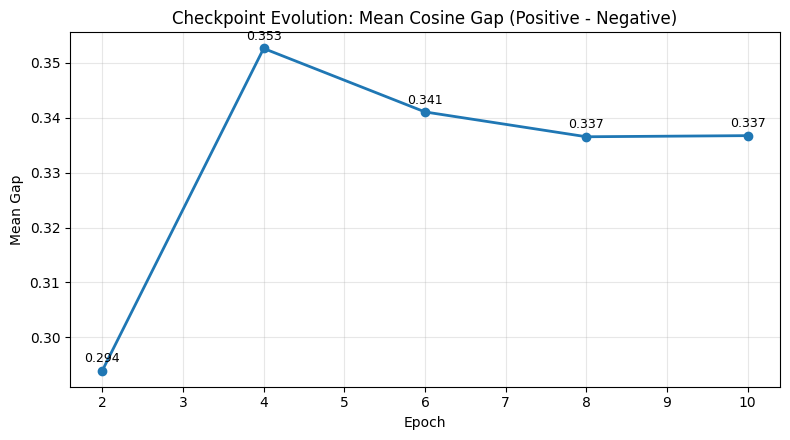

In [8]:
# Plot mean gap (mean_positive - mean_negative) across checkpoints.

import matplotlib.pyplot as plt

if 'multi_ckpt_metrics_df' not in globals() or multi_ckpt_metrics_df.empty:
    raise RuntimeError('multi_ckpt_metrics_df not found or empty. Run the multi-checkpoint evaluation cell first.')

plot_df = multi_ckpt_metrics_df.sort_values('epoch').copy()

plt.figure(figsize=(8, 4.5))
plt.plot(
    plot_df['epoch'],
    plot_df['mean_gap_pos_minus_neg'],
    marker='o',
    linewidth=2,
)

for _, r in plot_df.iterrows():
    plt.annotate(f"{r['mean_gap_pos_minus_neg']:.3f}", (r['epoch'], r['mean_gap_pos_minus_neg']), textcoords='offset points', xytext=(0, 6), ha='center', fontsize=9)

plt.title('Checkpoint Evolution: Mean Cosine Gap (Positive - Negative)')
plt.xlabel('Epoch')
plt.ylabel('Mean Gap')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
